## Entrenamiento para modelo trifasico

Cargando dataset de características desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet
Columnas de características: ['rms_V0mag', 'rms_V1mag', 'rms_V2mag', 'profundidad_V1mag', 'vuf', 'rms_asymmetry_ratio', 'unbalance_index', 'min_corr_abc', 'wavelet_energia_cD1_V0mag', 'fase_afectada_A', 'fase_afectada_B', 'fase_afectada_C', 'fase_afectada_N']
Dataset listo con 32800 señales y 13 características.

--- Comparando modelos con Validación Cruzada (sobre el conjunto de entrenamiento) ---

Evaluando Logistic Regression...

Evaluando SVM...

Evaluando k-NN...

Evaluando Random Forest...

Evaluando XGBoost...

--- Tabla Resumen (Resultados de CV en el conjunto de entrenamiento) ---
              Model  Accuracy (CV)  Precision (macro)  Recall (macro)  F1-Score (macro)
Logistic Regression       0.988284           0.988332        0.988284          0.988290
                SVM       0.989199           0.989417     

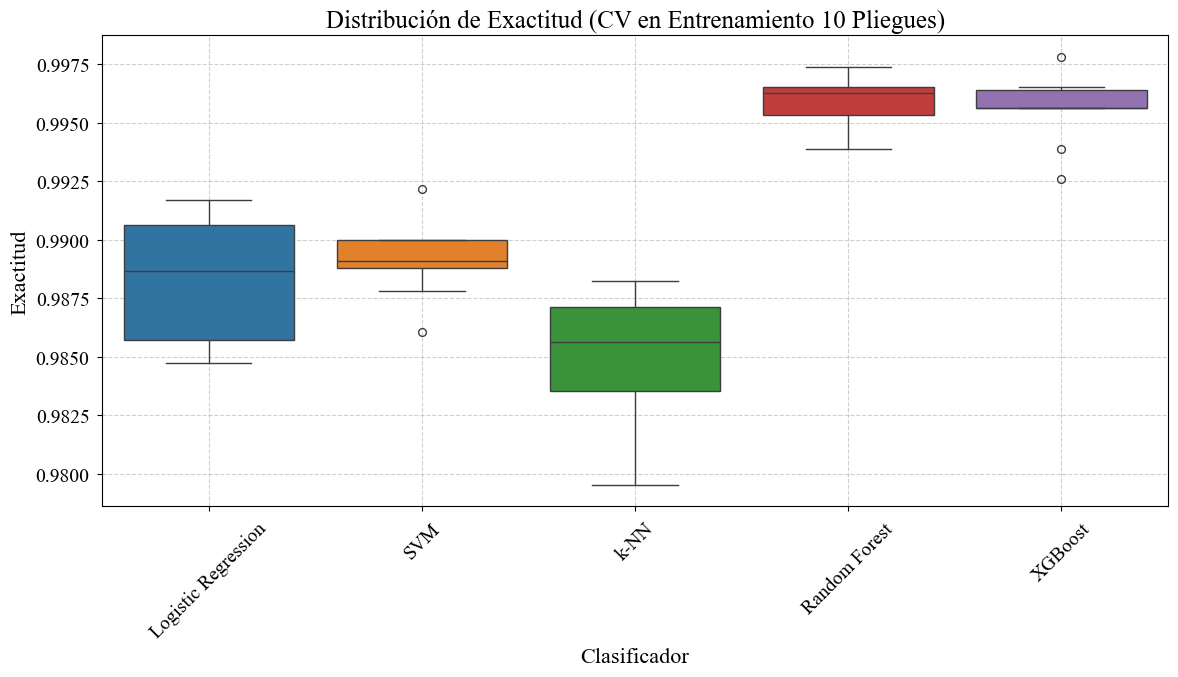

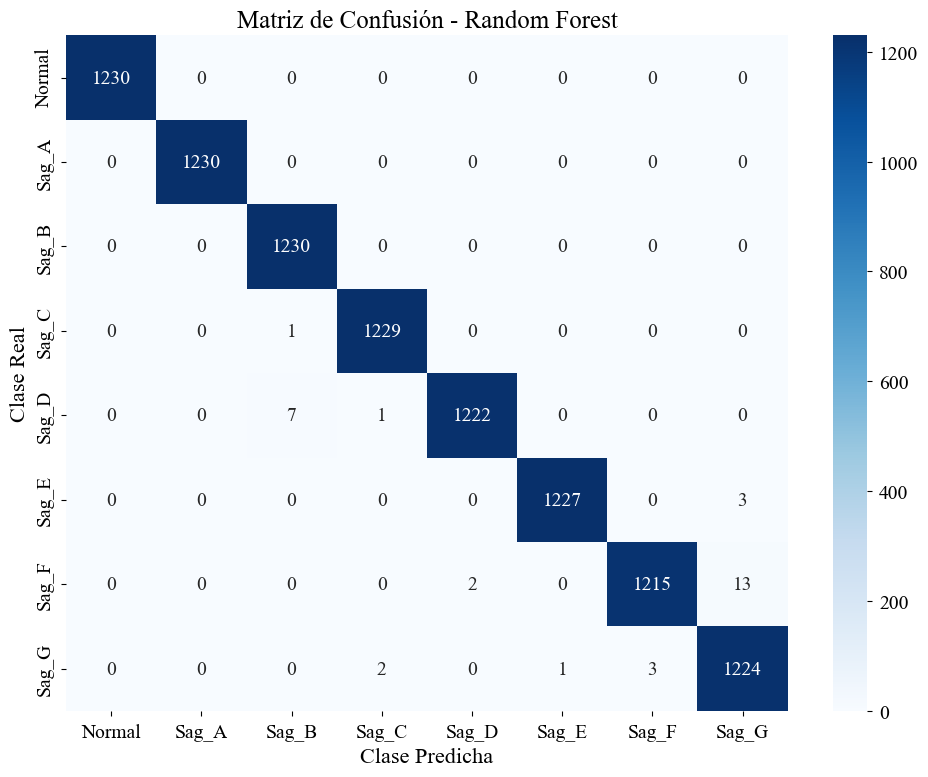

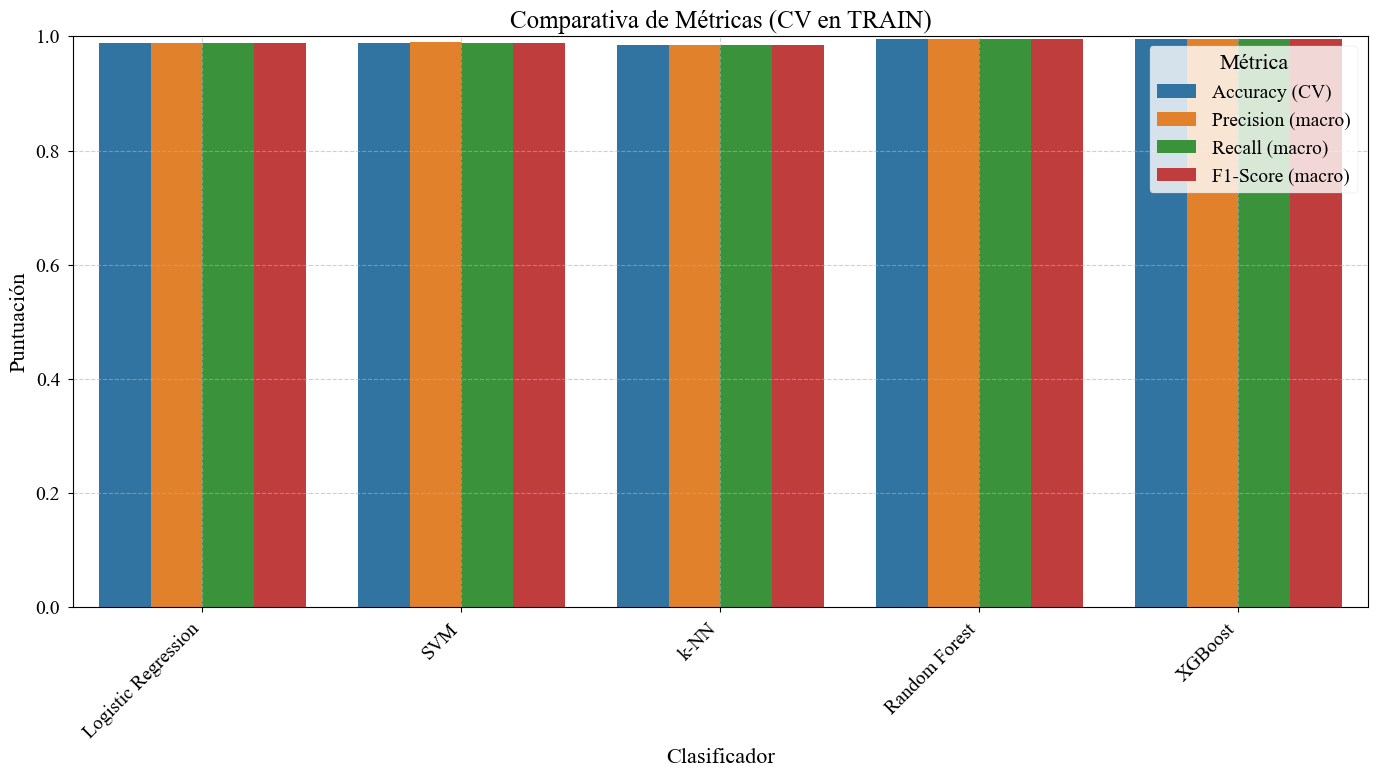

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 14,
        'axes.labelsize': 16, 'axes.titlesize': 18,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.figsize': (10, 6),
        'lines.linewidth': 2
    })

# ---------- Carga de datos ----------
# --- CAMBIO 1: Apuntar al nuevo dataset con características 100% numéricas ---
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet"
print(f"Cargando dataset de características desde: {data_path}")
df = pd.read_parquet(data_path)
# No es necesario reset_index si 'signal_id' ya es el índice
# df = df.reset_index() 

# ---------- Preparación y Preprocesamiento de Datos ----------
# Separa etiquetas (y) y características (X)
y = df['etiqueta']
# Ya no es necesario quitar 'signal_id' si es el índice. Si es una columna, esta línea es correcta.
X = df.drop(columns=['etiqueta']) 

# Codifica las etiquetas de texto a números (para y)
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

# --- CAMBIO 2: Lógica de preprocesamiento simplificada ---
# Se elimina el paso pd.get_dummies porque X ya es completamente numérico.
print("Columnas de características:", X.columns.tolist())
print(f"Dataset listo con {X.shape[0]} señales y {X.shape[1]} características.")

# ---------- Split en Train y Test (estratificado) ----------
# Ahora usamos X directamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

# ---------- Definición de Pipelines y Modelos (sin cambios) ----------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        # No se necesita escalador para modelos basados en árboles
        ('clf', RandomForestClassifier(n_estimators=50, class_weight='balanced_subsample', random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        # No se necesita escalador para modelos basados en árboles
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob', eval_metric='mlogloss',
            num_class=len(class_names), tree_method='hist',
            n_estimators=50, use_label_encoder=False, random_state=42, n_jobs=-1
        ))
    ])
}

# ---------- Entrenamiento, Evaluación y Visualización (sin cambios) ----------
_setup_academic_style()
print("\n--- Comparando modelos con Validación Cruzada (sobre el conjunto de entrenamiento) ---")
results_rows = []
all_accuracies = {}

for name, pipe in models.items():
    print(f"\nEvaluando {name}...")
    # Usamos cross_val_score para obtener las métricas de forma más limpia y eficiente
    accs = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    prec_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='precision_macro', n_jobs=-1)
    rec_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall_macro', n_jobs=-1)
    f1_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    all_accuracies[name] = accs
    results_rows.append({
        'Model': name,
        'Accuracy (CV)': np.mean(accs),
        'Precision (macro)': np.mean(prec_macro),
        'Recall (macro)': np.mean(rec_macro),
        'F1-Score (macro)': np.mean(f1_macro)
    })

results_df = pd.DataFrame(results_rows)
print("\n--- Tabla Resumen (Resultados de CV en el conjunto de entrenamiento) ---")
print(results_df.to_string(index=False))

best_model_name = results_df.sort_values(by='F1-Score (macro)', ascending=False).iloc[0]['Model']
best_pipe = models[best_model_name]

print(f"\n--- Re-entrenando el mejor modelo ({best_model_name}) con todos los datos de entrenamiento... ---")
best_pipe.fit(X_train, y_train)

print(f"\n=== Evaluación final del mejor modelo en el conjunto de PRUEBA (datos nunca vistos) ===")
y_test_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=class_names))


# ---------- Visualizaciones ----------
# 1) Boxplot accuracies CV (TRAIN)
plt.figure(figsize=(12, 7))
sns.boxplot(data=pd.DataFrame(all_accuracies))
plt.title('Distribución de Exactitud (CV en Entrenamiento 10 Pliegues)')
plt.ylabel('Exactitud')
plt.xlabel('Clasificador')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Validación_Cruzada_Tri.svg")
plt.show()

# 2) Matriz de confusión en TEST
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.savefig("Matriz_Confusón_Tri.svg")
plt.show()

# 3) Barras de métricas (CV en TRAIN)
metrics_to_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_to_plot)
plt.title('Comparativa de Métricas (CV en TRAIN)')
plt.ylabel('Puntuación')
plt.xlabel('Clasificador')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0)
plt.legend(title='Métrica')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Importaciones de Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import xgboost as xgb

# (Tu función de estilo _setup_academic_style va aquí...)

# ---------- 1. Carga y Preprocesamiento de Datos ----------
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_2.parquet"
print(f"Cargando dataset de características desde: {data_path}")
df = pd.read_parquet(data_path)
df = df.reset_index()

y = df['etiqueta']
X = df.drop(columns=['signal_id', 'etiqueta'])

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

print("Aplicando One-Hot Encoding...")
X_encoded = pd.get_dummies(X)

print(f"Dataset listo con {X_encoded.shape[0]} señales y {X_encoded.shape[1]} características.")

# ---------- 2. Split en Train y Test ----------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

# ---------- 3. Optimización de Hiperparámetros con RandomizedSearchCV ----------

# Define el modelo base
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(np.unique(y_enc)),
    tree_method='hist',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Define el espacio de búsqueda de parámetros
# Usamos distribuciones para una búsqueda más inteligente
param_grid = {
    'n_estimators': randint(300, 800),
    'max_depth': randint(5, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3), # Rango [0.7, 1.0]
    'colsample_bytree': uniform(0.7, 0.3), # Rango [0.7, 1.0]
    'gamma': uniform(0, 0.5)
}

# Configura la búsqueda aleatoria
# n_iter = 50 significa que probará 50 combinaciones al azar. Aumenta para una búsqueda más exhaustiva.
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=50,  # Número de combinaciones a probar
    scoring='f1_macro', # Métrica a optimizar
    cv=StratifiedKFold(n_splits=5),
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\n--- Iniciando la búsqueda de los mejores hiperparámetros para XGBoost ---")
# ⏳ ¡Este paso puede tardar varios minutos!
random_search.fit(X_train, y_train)

# Muestra los mejores parámetros encontrados
print("\n--- Búsqueda completada ---")
print("Mejores parámetros encontrados:")
print(random_search.best_params_)
print(f"Mejor F1-Score (macro) durante la CV: {random_search.best_score_:.4f}")


# ---------- 4. Evaluación Final del Mejor Modelo ----------
# El 'best_estimator_' es el mejor modelo, ya re-entrenado con todos los datos de train
best_model = random_search.best_estimator_

print(f"\n=== Evaluación final del modelo optimizado en el conjunto de PRUEBA ===")
y_test_pred = best_model.predict(X_test)

# Reporte de Clasificación
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_test_pred)
# (Tu código para graficar la matriz de confusión va aquí...)

Cargando dataset de características desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_2.parquet
Aplicando One-Hot Encoding...
Dataset listo con 32800 señales y 15 características.

--- Iniciando la búsqueda de los mejores hiperparámetros para XGBoost ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:54:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Búsqueda completada ---
Mejores parámetros encontrados:
{'colsample_bytree': np.float64(0.7242559978998145), 'gamma': np.float64(0.18482722803070223), 'learning_rate': np.float64(0.05843198765548518), 'max_depth': 10, 'n_estimators': 579, 'subsample': np.float64(0.8410901903338115)}
Mejor F1-Score (macro) durante la CV: 0.9656

=== Evaluación final del modelo optimizado en el conjunto de PRUEBA ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1230
       Sag_A       1.00      0.98      0.99      1230
       Sag_B       1.00      1.00      1.00      1230
       Sag_C       0.86      0.91      0.88      1230
       Sag_D       0.93      0.86      0.89      1230
       Sag_E       0.94      0.97      0.96      1230
       Sag_F       1.00      1.00      1.00      1230
       Sag_G       1.00      1.00      1.00      1230

    accuracy                           0.96      9840
   macro avg       0.96      0.96      0.96      98

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib # Necesitas esta importación para guardar/cargar modelos

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
# Importaciones de modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# --- Configuración del entorno ---
def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    # (El código de estilo se mantiene igual)
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 14,
        'axes.labelsize': 16, 'axes.titlesize': 18,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.figsize': (10, 6),
        'lines.linewidth': 2
    })

# --- Rutas de guardado ---
# Crea una carpeta para los activos trifásicos si no existe
RUTA_MODELOS_TRIFASICO = r'Modelos\Tri' 
os.makedirs(RUTA_MODELOS_TRIFASICO, exist_ok=True)
print(f"Los artefactos del modelo se guardarán en: {RUTA_MODELOS_TRIFASICO}")

# ---------- Carga de datos ----------
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet"
print(f"\nCargando dataset de características desde: {data_path}")
df = pd.read_parquet(data_path)

# ---------- Preparación y Preprocesamiento de Datos ----------
y = df['etiqueta']
X = df.drop(columns=['etiqueta']) 

# Codifica las etiquetas de texto a números (IMPORTANTE: El encoder debe guardarse)
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

print("Columnas de características:", X.columns.tolist())
print(f"Dataset listo con {X.shape[0]} señales y {X.shape[1]} características.")

# Obtener los nombres de las columnas antes del split (IMPORTANTE: La lista de columnas debe guardarse)
model_columns = X.columns.tolist()

# ---------- Split en Train y Test (estratificado) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

# ---------- Definición de Pipelines y Modelos ----------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob', eval_metric='mlogloss',
            num_class=len(class_names), tree_method='hist',
            n_estimators=400, use_label_encoder=False, random_state=42, n_jobs=-1
        ))
    ])
}

# ---------- Entrenamiento, Evaluación y Visualización ----------
_setup_academic_style()
print("\n--- Comparando modelos con Validación Cruzada (sobre el conjunto de entrenamiento) ---")
results_rows = []
all_accuracies = {}

# (El código de CV y llenado de results_df se mantiene igual)
for name, pipe in models.items():
    print(f"\nEvaluando {name}...")
    accs = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    prec_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='precision_macro', n_jobs=-1)
    rec_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall_macro', n_jobs=-1)
    f1_macro = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    all_accuracies[name] = accs
    results_rows.append({
        'Model': name,
        'Accuracy (CV)': np.mean(accs),
        'Precision (macro)': np.mean(prec_macro),
        'Recall (macro)': np.mean(rec_macro),
        'F1-Score (macro)': np.mean(f1_macro)
    })

results_df = pd.DataFrame(results_rows)
print("\n--- Tabla Resumen (Resultados de CV en el conjunto de entrenamiento) ---")
print(results_df.to_string(index=False))

best_model_name = results_df.sort_values(by='F1-Score (macro)', ascending=False).iloc[0]['Model']
best_pipe = models[best_model_name]

print(f"\n--- Re-entrenando el mejor modelo ({best_model_name}) con todos los datos de entrenamiento... ---")
best_pipe.fit(X_train, y_train)

print(f"\n=== Evaluación final del mejor modelo en el conjunto de PRUEBA (datos nunca vistos) ===")
y_test_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=class_names))

# --------------------------------------------------------------------------------
# Guardar el Modelo, Encoder y Columnas
# --------------------------------------------------------------------------------
print(f"\n--- Guardando artefactos del modelo trifásico ({best_model_name})... ---")

# 1. Guardar el modelo (el mejor Pipeline ajustado)
joblib.dump(best_pipe, os.path.join(RUTA_MODELOS_TRIFASICO, 'modelo_trifasico.joblib'))

# 2. Guardar el LabelEncoder (necesario para convertir predicciones numéricas a texto)
joblib.dump(le, os.path.join(RUTA_MODELOS_TRIFASICO, 'label_encoder_trifasico.joblib'))

# 3. Guardar las columnas de características (necesario para asegurar el orden de las features al predecir)
joblib.dump(model_columns, os.path.join(RUTA_MODELOS_TRIFASICO, 'model_columns_trifasico.joblib'))

print("¡Archivos del modelo trifásico guardados exitosamente!")

Los artefactos del modelo se guardarán en: Modelos\Tri

Cargando dataset de características desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet
Columnas de características: ['rms_V0mag', 'rms_V1mag', 'rms_V2mag', 'profundidad_V1mag', 'vuf', 'rms_asymmetry_ratio', 'unbalance_index', 'min_corr_abc', 'wavelet_energia_cD1_V0mag', 'fase_afectada_A', 'fase_afectada_B', 'fase_afectada_C', 'fase_afectada_N']
Dataset listo con 32800 señales y 13 características.

--- Comparando modelos con Validación Cruzada (sobre el conjunto de entrenamiento) ---

Evaluando Logistic Regression...

Evaluando SVM...

Evaluando k-NN...

Evaluando Random Forest...

Evaluando XGBoost...

--- Tabla Resumen (Resultados de CV en el conjunto de entrenamiento) ---
              Model  Accuracy (CV)  Precision (macro)  Recall (macro)  F1-Score (macro)
Logistic Regression       0.987761           0.987797        0.987761          0.987767
  

Cargando el dataset de características...
Se encontraron 8 clases: ['Normal' 'Sag_A' 'Sag_B' 'Sag_C' 'Sag_D' 'Sag_E' 'Sag_F' 'Sag_G']

Escalando características originales (19D)...
Calculando la proyección t-SNE... (esto puede tardar)
Proyección t-SNE calculada. Forma: (32800, 2)
Las imágenes se guardarán en la carpeta: fronteras_de_decision

Iniciando el entrenamiento y graficación de los modelos 2D...
Entrenando y graficando Logistic Regression...
Guardando gráfico en: fronteras_de_decision\frontera_decision_Logistic_Regression.png


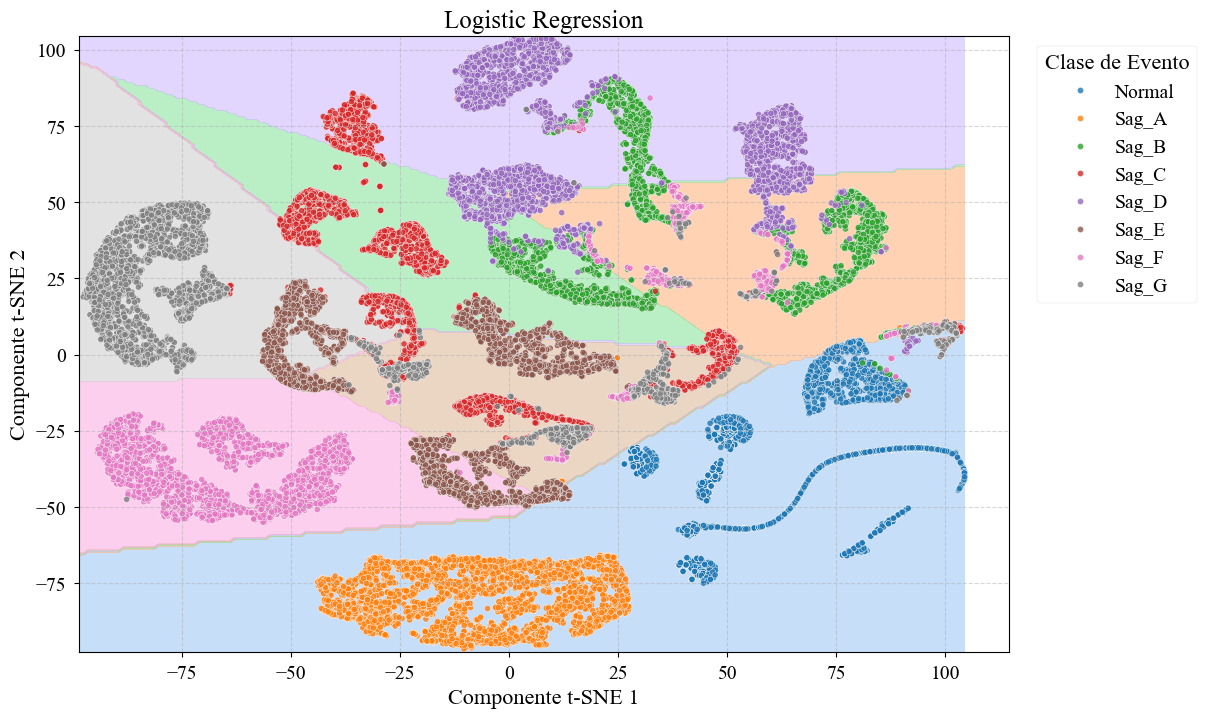

Entrenando y graficando SVM...
Guardando gráfico en: fronteras_de_decision\frontera_decision_SVM.png


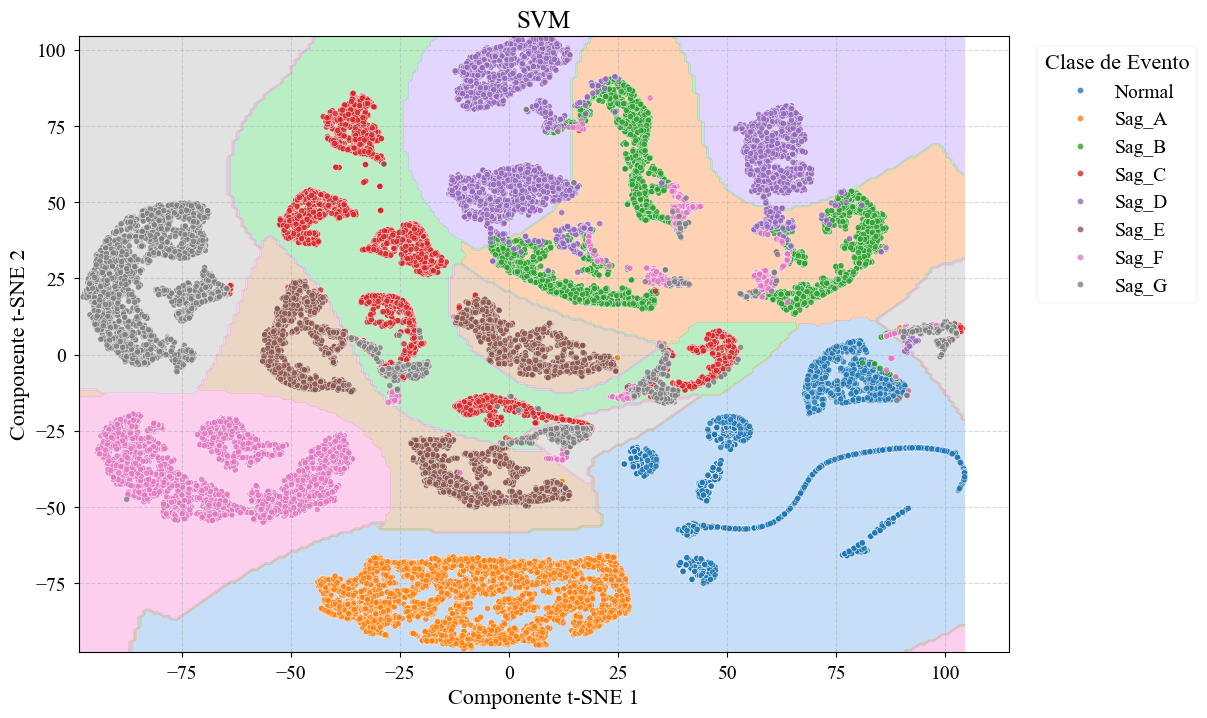

Entrenando y graficando k-NN...
Guardando gráfico en: fronteras_de_decision\frontera_decision_k_NN.png


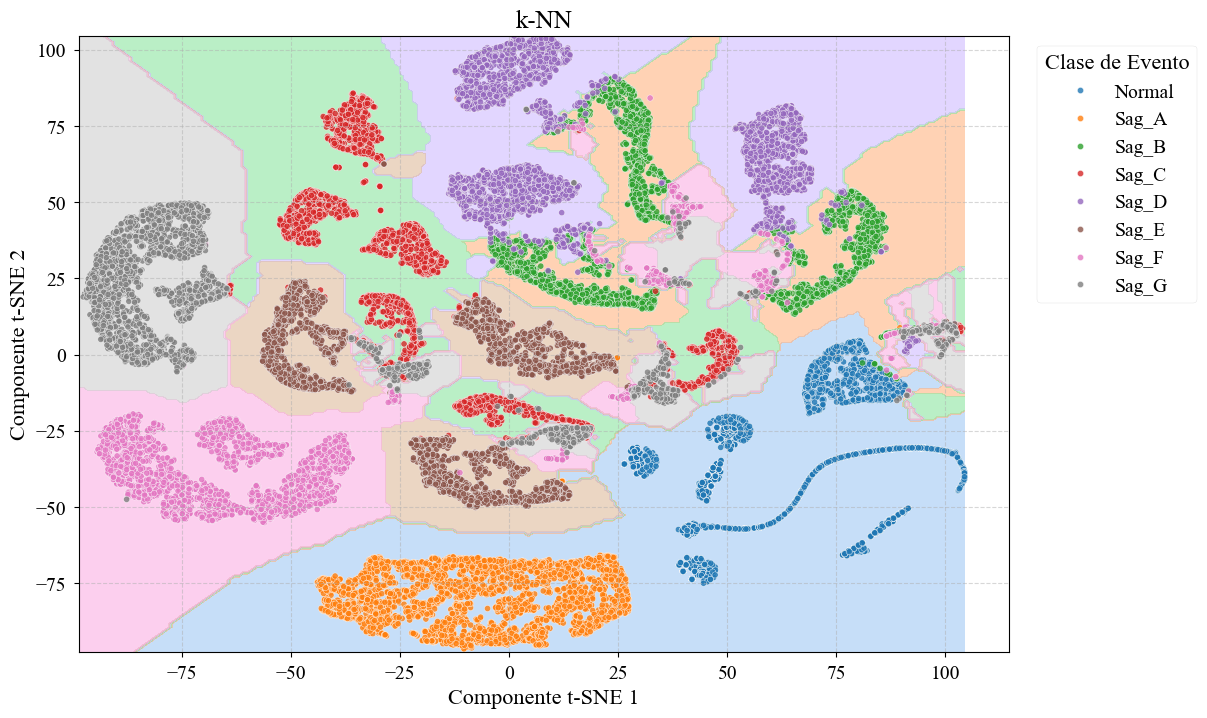

Entrenando y graficando Random Forest...
Guardando gráfico en: fronteras_de_decision\frontera_decision_Random_Forest.png


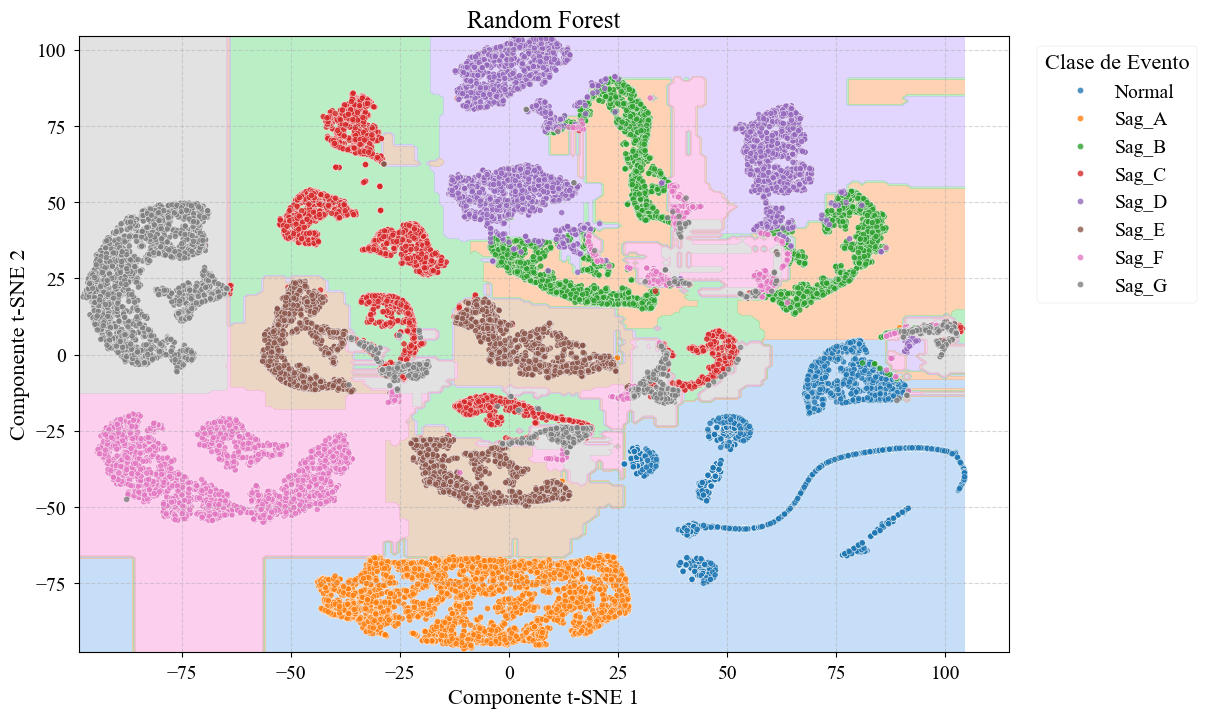

Entrenando y graficando XGBoost...


c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:41:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Guardando gráfico en: fronteras_de_decision\frontera_decision_XGBoost.png


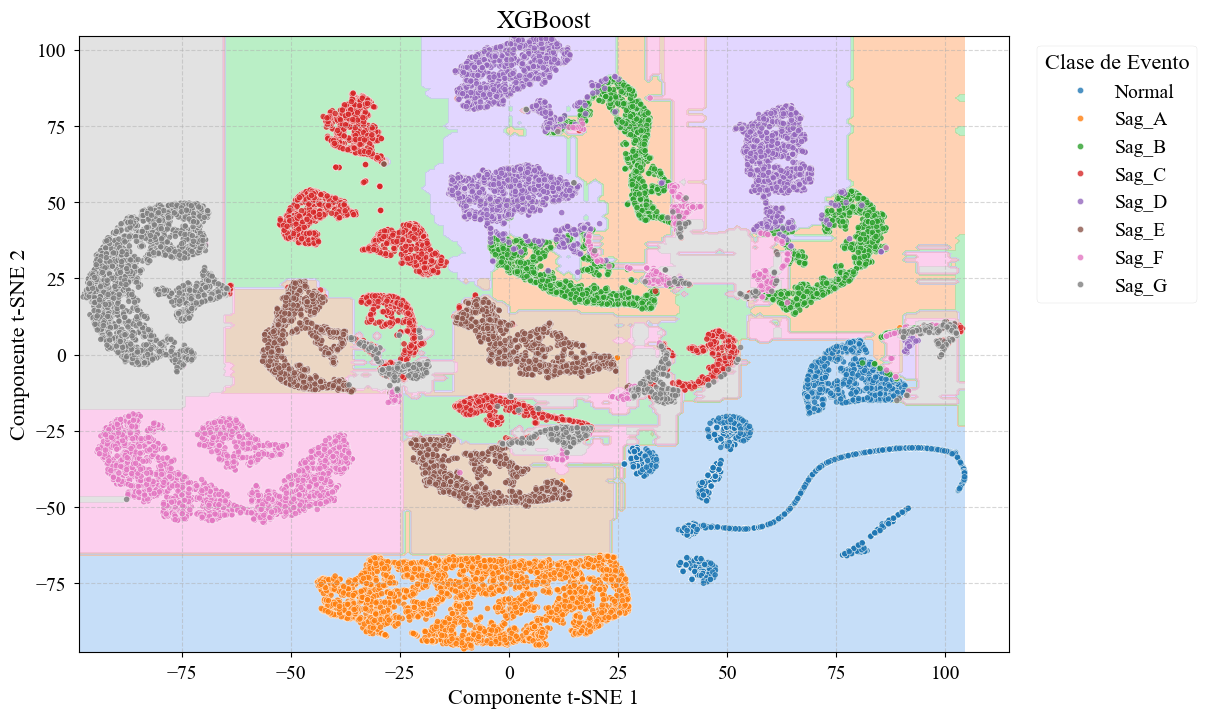


¡Todos los gráficos individuales han sido generados y guardados!
RECUERDA: Estas fronteras son de modelos 2D, no de tus modelos 19D.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Importación de todos los modelos ---
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import os # Importar os para crear una carpeta de guardado

# --- 1. Cargar y preparar los datos ---
print("Cargando el dataset de características...")
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Caracteristicas_Trifasico_5.parquet"
df = pd.read_parquet(data_path)

X = df.drop('etiqueta', axis=1)
y_texto = df['etiqueta'] # Etiquetas de texto para las leyendas

# Codificar etiquetas a números
le = LabelEncoder()
y_enc = le.fit_transform(y_texto)
class_names = le.classes_
print(f"Se encontraron {len(class_names)} clases: {class_names}")

# --- 2. Escalar las 19 características (para t-SNE) ---
print("\nEscalando características originales (19D)...")
scaler_19D = StandardScaler()
X_scaled_19D = scaler_19D.fit_transform(X) 

# --- 3. Cálculo de t-SNE ---
print("Calculando la proyección t-SNE... (esto puede tardar)")
tsne = TSNE(n_components=2, random_state=42, perplexity=60, 
            init='pca', learning_rate='auto', max_iter=1000)
# Usamos los datos escalados de 19D para calcular la proyección 2D
X_2D = tsne.fit_transform(X_scaled_19D)

print("Proyección t-SNE calculada. Forma:", X_2D.shape)

# Crear una carpeta para guardar las imágenes
output_dir = "fronteras_de_decision"
os.makedirs(output_dir, exist_ok=True)
print(f"Las imágenes se guardarán en la carpeta: {output_dir}")

# --- 4. Definir los modelos (Pipelines) ---
# (Esta sección es idéntica a la tuya)
models_2D = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        ('scaler', 'passthrough'), 
        ('clf', RandomForestClassifier(n_estimators=50, class_weight='balanced_subsample', random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', 'passthrough'), 
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob', eval_metric='mlogloss',
            num_class=len(class_names), tree_method='hist',
            n_estimators=50, use_label_encoder=False, random_state=42
        ))
    ])
}

# --- 5. Función para graficar las fronteras (MODIFICADA) ---

def plot_decision_boundary(clf, X, y_num, y_txt, ax, title):
    """
    Función para graficar la frontera de decisión y los puntos.
    AHORA INCLUYE Y FORMATEA LA LEYENDA.
    """
    
    # Crear un colormap para el fondo y los puntos
    n_classes = len(np.unique(y_num))
    cmap_light = ListedColormap(sns.color_palette("pastel", n_classes))
    cmap_bold = sns.color_palette("tab10", n_classes)
    
    # Definir los límites del gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Crear la "malla" (meshgrid) para el fondo
    # Ajustar 'h' para balancear velocidad y resolución
    h = (x_max - x_min) / 200  # Resolución media
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predecir la clase para cada punto de la malla
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar el fondo (la frontera de decisión)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    
    # Graficar los puntos de datos (el scatter plot)
    sns.scatterplot(
        x=X[:, 0], y=X[:, 1],
        hue=y_txt, # Usar las etiquetas de texto para la leyenda
        palette=cmap_bold,
        alpha=0.8, s=20,
        ax=ax,
        legend="full" # <-- CAMBIO: Habilitamos la leyenda
    )
    
    # --- CAMBIO: Formatear la leyenda para artículo ---
    legend = ax.get_legend()
    legend.set_title('Clase de Evento')
    legend.set_bbox_to_anchor((1.02, 1)) # Moverla fuera del gráfico
    legend.loc = 'upper left'
    
    # Título del gráfico (solo el nombre del modelo)
    ax.set_title(title)
    ax.set_xlabel('Componente t-SNE 1')
    ax.set_ylabel('Componente t-SNE 2')
    ax.grid(True, linestyle='--', alpha=0.5)

# --- 6. Entrenar y Graficar cada modelo (MODIFICADO) ---
print("\nIniciando el entrenamiento y graficación de los modelos 2D...")

# Configurar el estilo académico (letras más grandes para leyenda)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 'font.size': 14,
    'axes.labelsize': 16, 'axes.titlesize': 18,
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14,         # Tamaño de ítems de leyenda
    'legend.title_fontsize': 16, # Tamaño de título de leyenda
    'figure.figsize': (12, 8)      # Tamaño por defecto para una figura
})

# --- Bucle MODIFICADO para gráficos individuales ---
for name, model in models_2D.items():
    print(f"Entrenando y graficando {name}...")
    
    # 1. Crear una NUEVA figura y ejes para CADA modelo
    fig, ax = plt.subplots(figsize=(12, 8)) # Puedes ajustar este tamaño
    
    # 2. Entrenar el modelo 2D
    model.fit(X_2D, y_enc)
    
    # 3. Graficar (la función ahora pasa y_texto para la leyenda)
    plot_decision_boundary(model, X_2D, y_enc, y_texto, ax, name)
    
    # 4. Ajustar el layout para que quepa la leyenda
    # plt.tight_layout(rect=[0, 0, 0.85, 1]) # Ajuste manual
    
    # 5. Guardar la figura individual
    # (reemplazamos caracteres especiales para nombres de archivo válidos)
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
    save_filename = os.path.join(output_dir, f"frontera_decision_{safe_name}.png")
    print(f"Guardando gráfico en: {save_filename}")
    
    # bbox_inches='tight' es CRUCIAL para guardar la leyenda externa
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    
    # 6. Mostrar el gráfico
    plt.show()
    
    # 7. Cerrar la figura para liberar memoria
    plt.close(fig)

print("\n¡Todos los gráficos individuales han sido generados y guardados!")
print("RECUERDA: Estas fronteras son de modelos 2D, no de tus modelos 19D.")